# CMIIC - Meek Rule R3

**Problème** : ContinuousMIIC dans sa version original d'otagrum semble se tromper dans la Meek Rule R3.

Illustration avec l'exemple suivant.

Golden DAG `0 → 1 ← 2 → 3` avec 100 samples et alpha = 0,01.

Rappel R3 : https://theses.hal.science/tel-03647090/file/LASSERRE_Marvin_these_2022.pdf#page=105

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import openturns as ot
import otagrum

## DAG golden et données synthétiques

In [2]:
# DAG: X0 → X1, X2 → X1, X2 → X3
dag = gum.DAG()
dag.addNodes(4)
for t, h in [(0, 1), (2, 1), (2, 3)]:
    dag.addArc(t, h)

var_names = [f"X{i}" for i in range(4)]
named_dag = otagrum.NamedDAG(dag, var_names)

# Marginales uniformes
marginals = [ot.Uniform(0.0, 1.0) for _ in range(4)]

# Copules locales conditionnelles (corrélation gaussienne = 0.8)
rho = 0.8
local_copulas = []
for i in range(4):
    n_parents = named_dag.getParents(i).getSize()
    dim = n_parents + 1
    R = ot.CorrelationMatrix(dim)
    for j in range(dim):
        for k in range(j): # k < j => la diagonale est à 1
            R[j, k] = rho # fait aussi R[k, j] = rho
    local_copulas.append(ot.NormalCopula(R))

cbn = otagrum.ContinuousBayesianNetwork(named_dag, marginals, local_copulas)

# Générer données
ot.RandomGenerator.SetSeed(42)
sample = cbn.getSample(100)

# Golden CPDAG via EssentialGraph
bn = gum.BayesNet()
for nid in dag.nodes():
    bn.add(gum.LabelizedVariable(f"X{nid}", f"X{nid}", 2))
for nid in dag.nodes():
    for cid in dag.children(nid):
        bn.addArc(nid, cid)

golden_cpdag = gum.EssentialGraph(bn).pdag()

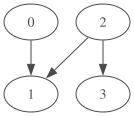

In [3]:
gnb.showDot(dag.toDot())

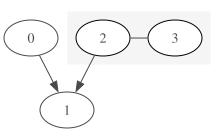

In [4]:
gnb.showDot(golden_cpdag.toDot())

## Apprentissage avec ContinuousMIIC v1

In [5]:
# Apprentissage CMIIC v1 (alpha=0.01)
learner = otagrum.ContinuousMIIC(sample)
learner.setAlpha(0.01)
learner.setVerbosity(False)

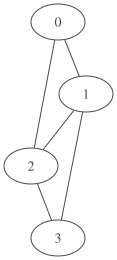

In [6]:
learned_skeleton = learner.learnSkeleton()
gnb.showDot(learned_skeleton.toDot())

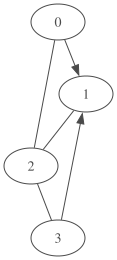

In [7]:
learned_pdag = learner.learnPDAG()
gnb.showDot(learned_pdag.toDot())

In [8]:
learned_named_dag = learner.learnDAG()
learned_dag = learned_named_dag.getDAG()

# Convertir en CPDAG via EssentialGraph
bn2 = gum.BayesNet()
for nid in learned_dag.nodes():
    bn2.add(gum.LabelizedVariable(f"X{nid}", f"X{nid}", 2))
for t, h in learned_dag.arcs():
    bn2.addArc(t, h)

learned_cpdag = gum.EssentialGraph(bn2).pdag()

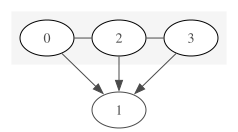

In [9]:
gnb.showDot(learned_cpdag.toDot())